In [59]:
import warnings

warnings.filterwarnings('ignore')

In [60]:
import drawdata

import matplotlib.pyplot as plt

In [10]:
widget = drawdata.ScatterWidget()
widget

In [21]:
data = widget.data_as_pandas

In [22]:
data.shape

(189, 5)

In [23]:
data.head()

,x,y,color,label,batch
0,122.964391,163.460921,#1f77b4,a,0
1,139.089095,163.454884,#1f77b4,a,0
2,125.784810,202.419428,#1f77b4,a,0
3,102.239905,210.986236,#1f77b4,a,0
4,133.296074,207.270043,#1f77b4,a,0


In [40]:
data.to_csv('datasets/simple.csv', index=False)

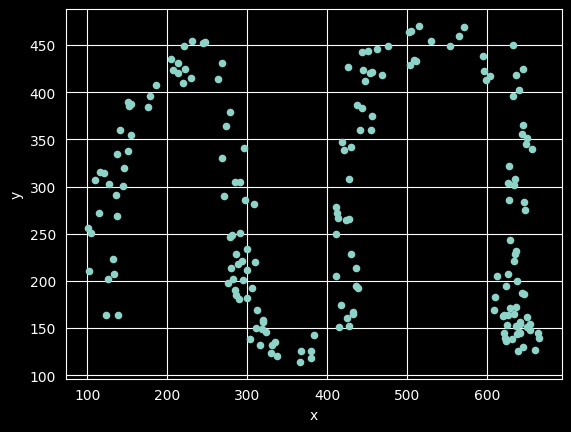

In [46]:
fig, ax = plt.subplots()

data.plot.scatter(x='x', y='y', ax=ax)

plt.show()

# Explore Bagging

6 different random forest with a single tree

In [47]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor

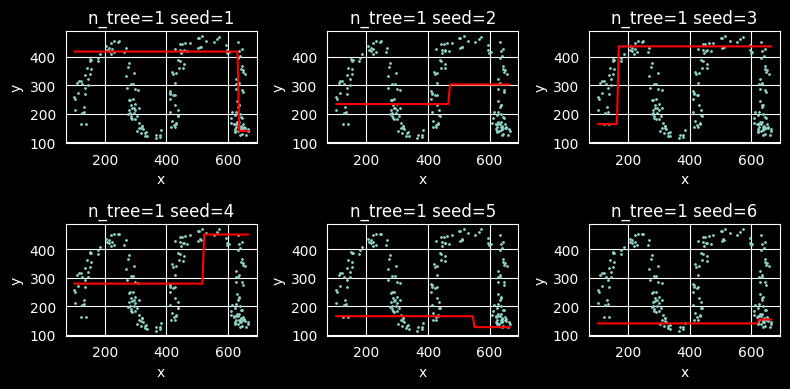

In [48]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1] * 6

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree} seed={i}', s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=i)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.predict(x)

    ax.plot(x, y, c='red')

fig.tight_layout()


In [25]:
np.linspace(0, 20, 100)

array([ 0.        ,  0.2020202 ,  0.4040404 ,  0.60606061,  0.80808081,
        1.01010101,  1.21212121,  1.41414141,  1.61616162,  1.81818182,
        2.02020202,  2.22222222,  2.42424242,  2.62626263,  2.82828283,
        3.03030303,  3.23232323,  3.43434343,  3.63636364,  3.83838384,
        4.04040404,  4.24242424,  4.44444444,  4.64646465,  4.84848485,
        5.05050505,  5.25252525,  5.45454545,  5.65656566,  5.85858586,
        6.06060606,  6.26262626,  6.46464646,  6.66666667,  6.86868687,
        7.07070707,  7.27272727,  7.47474747,  7.67676768,  7.87878788,
        8.08080808,  8.28282828,  8.48484848,  8.68686869,  8.88888889,
        9.09090909,  9.29292929,  9.49494949,  9.6969697 ,  9.8989899 ,
       10.1010101 , 10.3030303 , 10.50505051, 10.70707071, 10.90909091,
       11.11111111, 11.31313131, 11.51515152, 11.71717172, 11.91919192,
       12.12121212, 12.32323232, 12.52525253, 12.72727273, 12.92929293,
       13.13131313, 13.33333333, 13.53535354, 13.73737374, 13.93

# random forest vs single tree

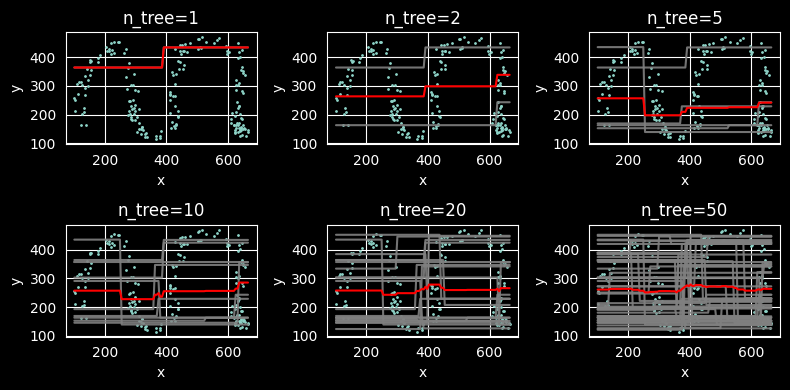

In [49]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree}', s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=42)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    for i, tree in enumerate(clf.estimators_):
        y = tree.predict(x)
        ax.plot(x, y, c='gray', alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c='red')

fig.tight_layout()


In [57]:
from ipywidgets import interact, IntSlider, FloatSlider

In [55]:
def plot_random_forest(data_path, max_depth, max_samples):
    layouts = """
    123
    456
    """


    plt.close('all')

    fig, axs = plt.subplot_mosaic(layouts, figsize=(8, 4))
    n_trees = [1, 2, 5, 10, 20, 50]

    data = pd.read_csv(data_path)

    for i, n_tree in enumerate(n_trees, start=1):
        ax = axs[str(i)]

        data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree} seed={i}', s=1)

        clf = RandomForestRegressor(n_estimators=n_tree, max_depth=max_depth, max_samples=max_samples, random_state=42)
        clf.fit(data[['x']], data['y'])

        x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
        })

        for i, tree in enumerate(clf.estimators_):
            y = tree.predict(x)
            ax.plot(x, y, c='gray', alpha=0.9)

        y = clf.predict(x)
        ax.plot(x, y, c='red')

    fig.tight_layout()
    plt.show()


In [58]:
max_depth_slider = IntSlider(min=1, max=10, value=3, description='Max depth')
max_samples_slider = FloatSlider(min=0.01, max=1.0, step=0.01 , value=0.1, description='Max Sample' )

interact(
    plot_random_forest,
    data_path='datasets/simple.csv',
    max_depth=max_depth_slider,
    max_samples=max_samples_slider
)

interactive(children=(Text(value='datasets/simple.csv', description='data_path'), IntSlider(value=3, descripti…

<function __main__.plot_random_forest(data_path, max_depth, max_samples)>

---

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn import set_config

In [2]:
set_config(transform_output='pandas')

In [3]:
adult_data = fetch_openml(data_id=1590)
X = adult_data.data
y = adult_data.target

In [4]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [5]:
y.head()

0    <=50K
1    <=50K
2     >50K
3     >50K
4    <=50K
Name: class, dtype: category
Categories (2, object): ['<=50K', '>50K']

In [6]:
type(adult_data)

sklearn.utils._bunch.Bunch

In [7]:
(
    X
    .assign(y=y)
    .to_parquet('datasets/adult_copy.parquet')
)

In [18]:
adult = pd.read_parquet('datasets/adult.parquet')
X = adult.drop(columns='y')
y = adult.y

In [19]:
X.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [24]:
categorical_features = X.select_dtypes(include=['category']).columns
categorical_transformer = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [25]:
categorical_transformer.fit_transform(X.iloc[:, :2])

,age_17,age_18,age_19,age_20,age_21,age_22,age_23,age_24,age_25,age_26,...,age_90,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_missing
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48839,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48840,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [26]:
categorical_transformer.fit_transform(X[categorical_features])

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_missing,education_10th,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_missing
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48838,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48839,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48840,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [30]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [31]:
predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.818


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=20, max_samples=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.832


In [54]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_distributions = {
    "classifier__n_estimators": np.arange(50, 801, 50),
    "classifier__max_depth": [None, 3, 5, 8, 12, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None],
}

rnd = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

rnd.fit(X_train, y_train)

print("Best params:", rnd.best_params_)
print("Best CV accuracy:", rnd.best_score_)

y_pred = rnd.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

pd.DataFrame(rnd.cv_results_).sort_values("rank_test_score").head(10)[
    ["mean_test_score", "std_test_score", "mean_train_score", "params"]
]

Best params: {'classifier__n_estimators': np.int64(300), 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': None}
Best CV accuracy: 0.8317588223977692
Test accuracy: 0.8325257626424623


,mean_test_score,std_test_score,mean_train_score,params
27,0.831759,0.002541,0.834245,"{'classifier__n_estimators': 300, 'classifier_..."
23,0.830881,0.004376,0.840928,"{'classifier__n_estimators': 600, 'classifier_..."
12,0.830794,0.003973,0.844943,"{'classifier__n_estimators': 650, 'classifier_..."
24,0.830677,0.004539,0.840841,"{'classifier__n_estimators': 800, 'classifier_..."
28,0.830501,0.003968,0.840855,"{'classifier__n_estimators': 400, 'classifier_..."
11,0.830384,0.002902,0.834208,"{'classifier__n_estimators': 650, 'classifier_..."
0,0.830209,0.005714,0.846895,"{'classifier__n_estimators': 750, 'classifier_..."
22,0.830062,0.004072,0.837294,"{'classifier__n_estimators': 150, 'classifier_..."
26,0.829273,0.004502,0.849030,"{'classifier__n_estimators': 50, 'classifier__..."
1,0.828746,0.003267,0.831920,"{'classifier__n_estimators': 150, 'classifier_..."


# Boosting and Gradient Boosting

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression

import warnings

warnings.filterwarnings('ignore')

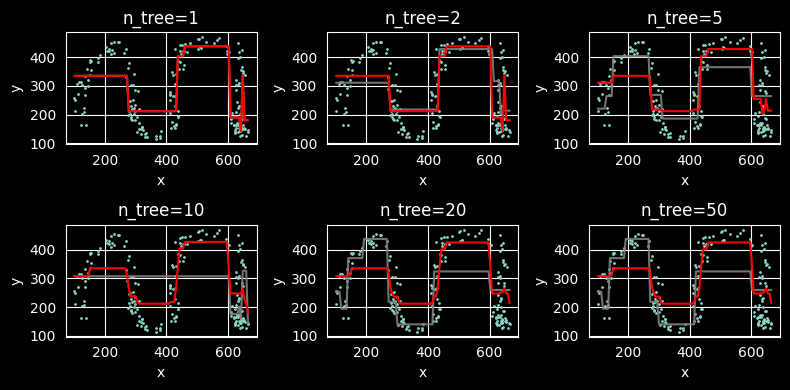

In [42]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree}', s=1)

    clf = AdaBoostRegressor(n_estimators=n_tree, estimator=DecisionTreeRegressor(max_depth=3), random_state=42)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_[-1].predict(x)
    ax.plot(x, y, c='grey', alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c='red')

fig.tight_layout()

In [43]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [44]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier())
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.824


## Gradient boosting

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

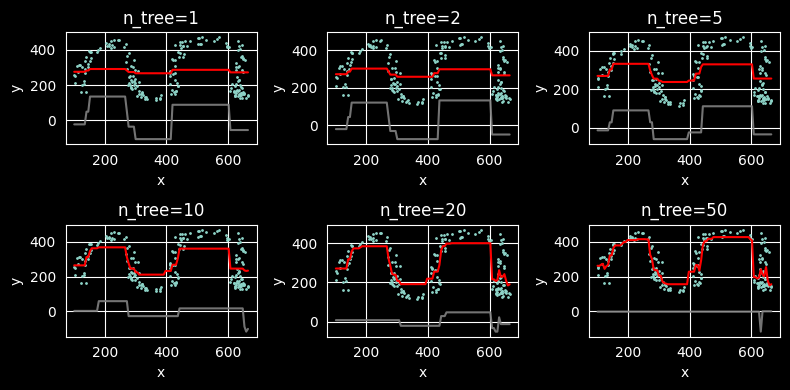

In [51]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv('datasets/simple.csv')

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]

    data.plot.scatter(x='x', y='y', ax=ax, title=f'n_tree={n_tree}', s=1)

    clf = GradientBoostingRegressor(n_estimators=n_tree, max_depth=3, random_state=42)
    clf.fit(data[['x']], data['y'])

    x = pd.DataFrame({
        'x': np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_.flatten()[-1].predict(x)
    ax.plot(x, y, c='grey', alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c='red')

fig.tight_layout()

In [50]:
np.array([[1, 2], [3, 4]]).flatten()

array([1, 2, 3, 4])

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

In [53]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f'Model Accuracy: {accuracy:.3f}')

Model Accuracy: 0.833
